In [193]:
here::i_am("snakemake/01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))
library(viridis)

# I/O
io$outdir =  file.path(io$output.directory,"cluster_annotation")
dir.create(io$outdir, showWarnings = FALSE)

# args
args = list()
args$matrix = 'PeakMatrix'

addArchRThreads(12)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-' 

In [21]:
metadata = ArchRProject@cellColData

In [135]:
meta_RNA = fread(file.path('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/RNA/metadata.csv'))[,-1]

### Proportions per celltype

In [26]:
# Plot proportions
pdf1 = table(meta_RNA$celltype, meta_RNA$stage)
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))
pdf1$Var3 = 'RNA'

pdf2 = table(metadata$predictedGroup_celltype_PeakMatrix.1, metadata$stage)
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))
pdf2$Var3 = 'ATAC'

props = rbind(pdf1, pdf2)
props = props[,c('Var1', 'Var2', 'Var3', 'Freq')]
props$Freq = as.numeric(props$Freq)

options(repr.plot.width=15, repr.plot.height=15)
p = ggplot(props, aes(Var1, Freq, fill=Var3)) + 
    geom_bar(stat='identity', position = "dodge") + 
    facet_wrap(~Var2, ncol=1) + 
    theme_bw() + 
    ylab('Proportion') + 
    theme(axis.text.x=element_text(angle=-90, vjust=0, hjust=0),
          axis.title.x=element_blank(),
         text = element_text(size=20)) 

pdf(sprintf("%s/celltype_proportions.pdf",io$outdir), width=14, height=12)
print(p)
dev.off()

png 
  2

### Celltype annotation per cluster

In [29]:
# Plot cluster - celltype heatmap
pdf2 = table(metadata$predictedGroup_celltype_TileMatrix.1, metadata$Clusters_PeakMatrix)
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

test = dcast(pdf2, Var1 ~ Var2, value.var='Freq')
rownames(test) = test$Var1
test$Var1 = NULL
test <- scale(t(test))

ord <- hclust( dist(test, method = "euclidean"), method = "ward.D" )$order

pdf2$Var2 <- factor(pdf2$Var2, levels = rownames(test)[ord])

options(repr.plot.width=15, repr.plot.height=10)

p = ggplot(pdf2, aes(Var2, Var1, fill=Freq)) + 
    geom_tile() + 
    scale_fill_viridis() + 
    theme(text=element_text(size = 15),
         axis.title = element_blank(),
         legend.position='none') 

pdf(sprintf("%s/celltype_per_cluster.pdf",io$outdir), width=14, height=12)
print(p)
dev.off()

Warning message in dcast(pdf2, Var1 ~ Var2, value.var = "Freq"):
“The dcast generic in data.table has been passed a data.frame and will attempt to redirect to the reshape2::dcast; please note that reshape2 is deprecated, and this redirection is now deprecated as well. Please do this redirection yourself like reshape2::dcast(pdf2). In the next version, this warning will become an error.”


png 
  2

In [180]:
# Plot cluster - celltype heatmap
pdf2 = table(metadata$predictedGroup_celltype_PeakMatrix.1, metadata$stage_clusters.3)
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

test = dcast(pdf2, Var1 ~ Var2, value.var='Freq')
rownames(test) = test$Var1
test$Var1 = NULL
test <- scale(t(test))

ord <- hclust( dist(test, method = "euclidean"), method = "ward.D" )$order

pdf2$Var2 <- factor(pdf2$Var2, levels = rownames(test)[ord])

options(repr.plot.width=15, repr.plot.height=10)

p = ggplot(pdf2, aes(Var2, Var1, fill=Freq)) + 
    geom_tile() + 
    scale_fill_viridis() + 
    theme(text=element_text(size = 15),
          axis.text.x = element_text(angle=-90, hjust=0, vjust=0),
         axis.title = element_blank(),
         legend.position='none') 

pdf(sprintf("%s/celltype_per_stagecluster.pdf",io$outdir), width=14, height=12)
print(p)
dev.off()

Warning message in dcast(pdf2, Var1 ~ Var2, value.var = "Freq"):
“The dcast generic in data.table has been passed a data.frame and will attempt to redirect to the reshape2::dcast; please note that reshape2 is deprecated, and this redirection is now deprecated as well. Please do this redirection yourself like reshape2::dcast(pdf2). In the next version, this warning will become an error.”


png 
  2

## Find markers per cluster

In [4]:
getAvailableMatrices(ArchRProject)

[1] "GeneIntegrationMatrix_PeakMatrix" "GeneIntegrationMatrix_TileMatrix"
[3] "GeneScoreMatrix"                  "MotifMatrix"                     
[5] "PeakMatrix"                       "TileMatrix"

In [5]:
find_markers = function(matrix, FDR=0.01, log2FC=1.25, ntop=4){
    markers <- getMarkerFeatures(
        ArchRProj = ArchRProject, 
        useMatrix = matrix, 
        groupBy = "Clusters_PeakMatrix",
        bias = c("TSSEnrichment", "log10(nFrags)"),
        testMethod = "wilcoxon"
    )
    saveRDS(markers, file.path(io$outdir, sprintf('markers_%s.rds', matrix)))

    heatmapGS <- plotMarkerHeatmap(
        seMarker = markers, 
        cutOff = sprintf("FDR <= %s & Log2FC >= %s", FDR, log2FC),
      nLabel = ntop,
      nPrint = ntop
    )

    options(repr.plot.width=15, repr.plot.height=8)
    ComplexHeatmap::draw(heatmapGS, heatmap_legend_side = "bot", annotation_legend_side = "bot")
    plotPDF(heatmapGS, name = paste0('heatmap_', matrix), width = 9, height = 40, ArchRProj = ArchRProject, addDOC = FALSE)   
}

 [1] "chr1:987719-988319"       "chr1:1236714-1237314"    
 [3] "chr1:70951712-70952312"   "chr1:129791295-129791895"
 [5] "chr1:2640-3240"           "chr1:4657-5257"          
 [7] "chr1:1188854-1189454"     "chr1:1189649-1190249"    
 [9] "chr1:193775859-193776459" "chr1:194818780-194819380"
[11] "chr1:351799-352399"       "chr1:618791-619391"      
[13] "chr1:212436-213036"       "chr1:947056-947656"      
[15] "chr1:2221156-2221756"     "chr1:19450744-19451344"  
[17] "chr1:14028765-14029365"   "chr1:17850591-17851191"  
[19] "chr1:615850-616450"       "chr1:4946613-4947213"    
[21] "chr1:74512193-74512793"   "chr1:98257061-98257661"  
[23] "chr1:41159324-41159924"   "chr1:65994323-65994923"  
[25] "chr1:6205580-6206180"     "chr1:7141571-7142171"    
[27] "chr1:3118305-3118905"     "chr1:7937869-7938469"    
[29] "chr1:6615203-6615803"     "chr1:14014280-14014880"  
[31] "chr1:19247811-19248411"   "chr1:33565699-33566299"  
[33] "chr1:3407622-3408222"     "chr1:6176937-6177537"  

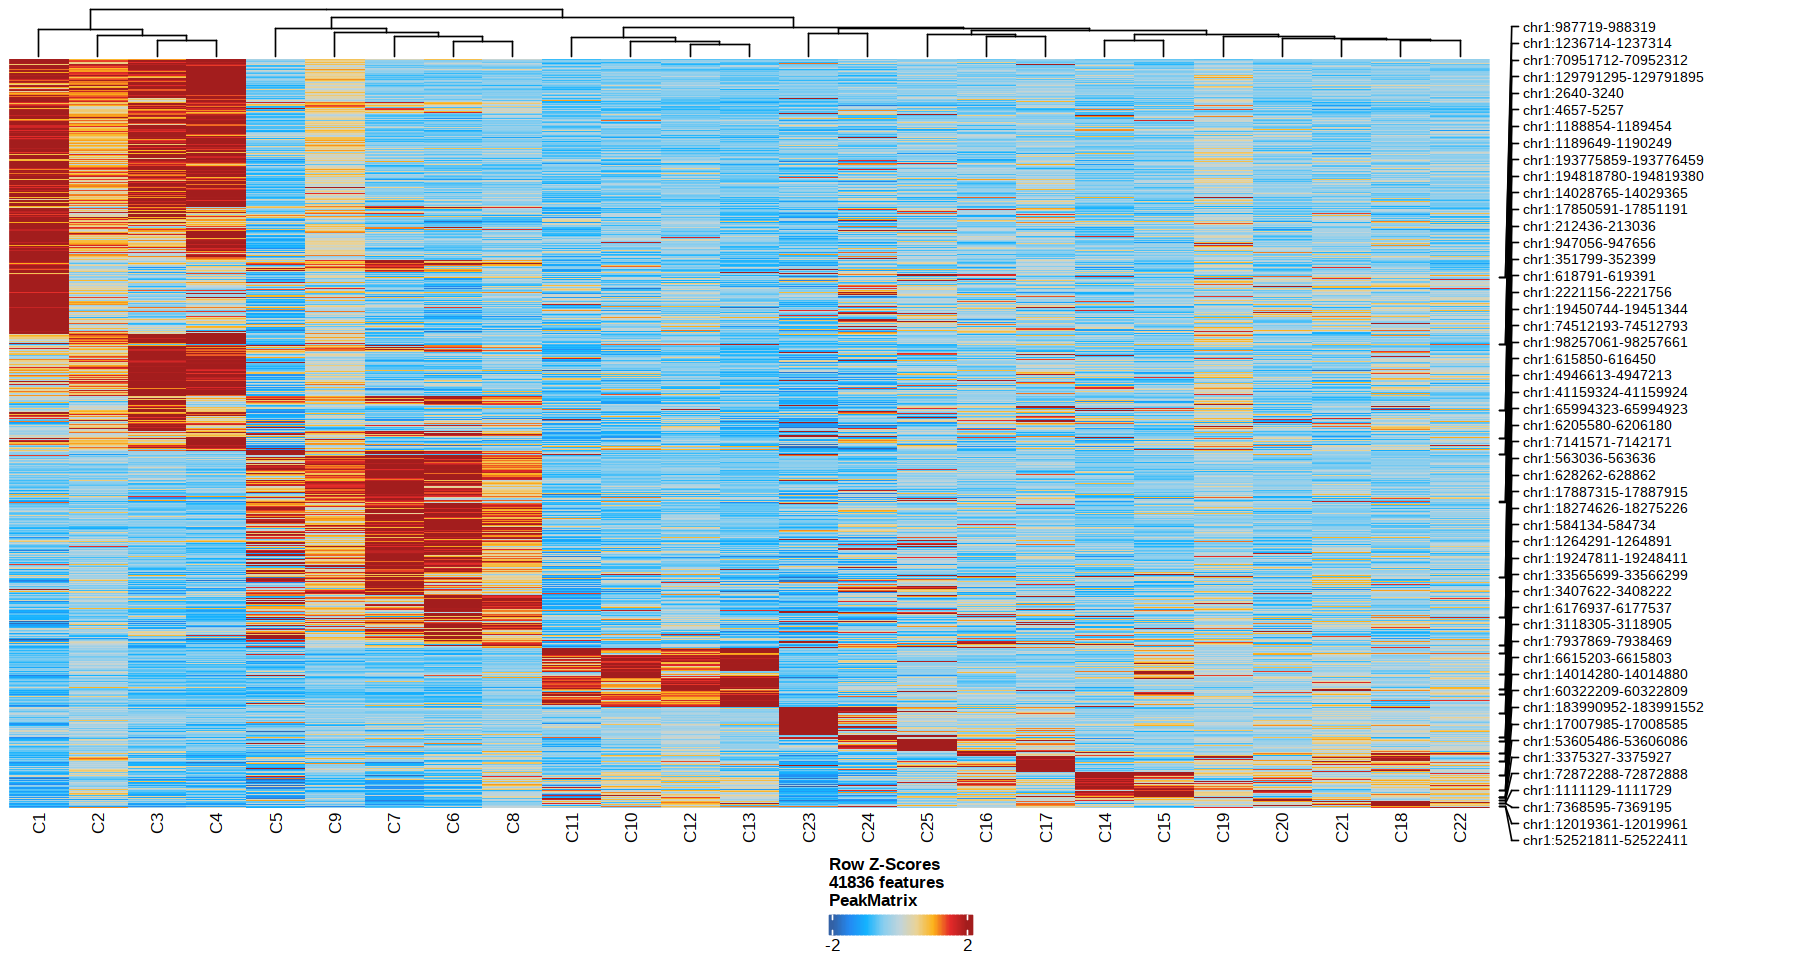

In [6]:
# Markers PeakMatrix
suppressMessages(find_markers('PeakMatrix', ntop=2))

 [1] "chr1:ENSOCUG00000029370"  "chr1:C9orf131"           
 [3] "chr1:ENSOCUG00000038592"  "chr1:ENSOCUG00000031086" 
 [5] "chr6:ENSOCUG00000030566"  "chr1:ENSOCUG00000023951" 
 [7] "chr1:ENSOCUG00000034626"  "chr2:ENSOCUG00000034389" 
 [9] "chr1:ENSOCUG00000035683"  "chr10:ENSOCUG00000036635"
[11] "chr10:ENSOCUG00000032947" "chr10:ENSOCUG00000037494"
[13] "chr1:ENSOCUG00000025587"  "chr1:DNAI1"              
[15] "chr1:ENSOCUG00000026028"  "chr1:OR9I1"              
[17] "chr1:ENSOCUG00000008405"  "chr1:U6"                 
[19] "chr1:MRPL11"              "chr1:DPP3"               
[21] "chr1:ENSOCUG00000034602"  "chr1:ocu-mir-100"        
[23] "chr1:ENSOCUG00000010359"  "chr1:WNT11"              
[25] "chr1:SNX30"               "chr1:PTBP3"              
[27] "chr1:NIPSNAP3A"           "chr1:ABCA1"              
[29] "chr2:ENSOCUG00000039121"  "chr13:U1"                
[31] "chr1:ENSOCUG00000027365"  "chr1:APOA4"              
[33] "chr15:AFP"                "chr6:ENSOCUG00000037160

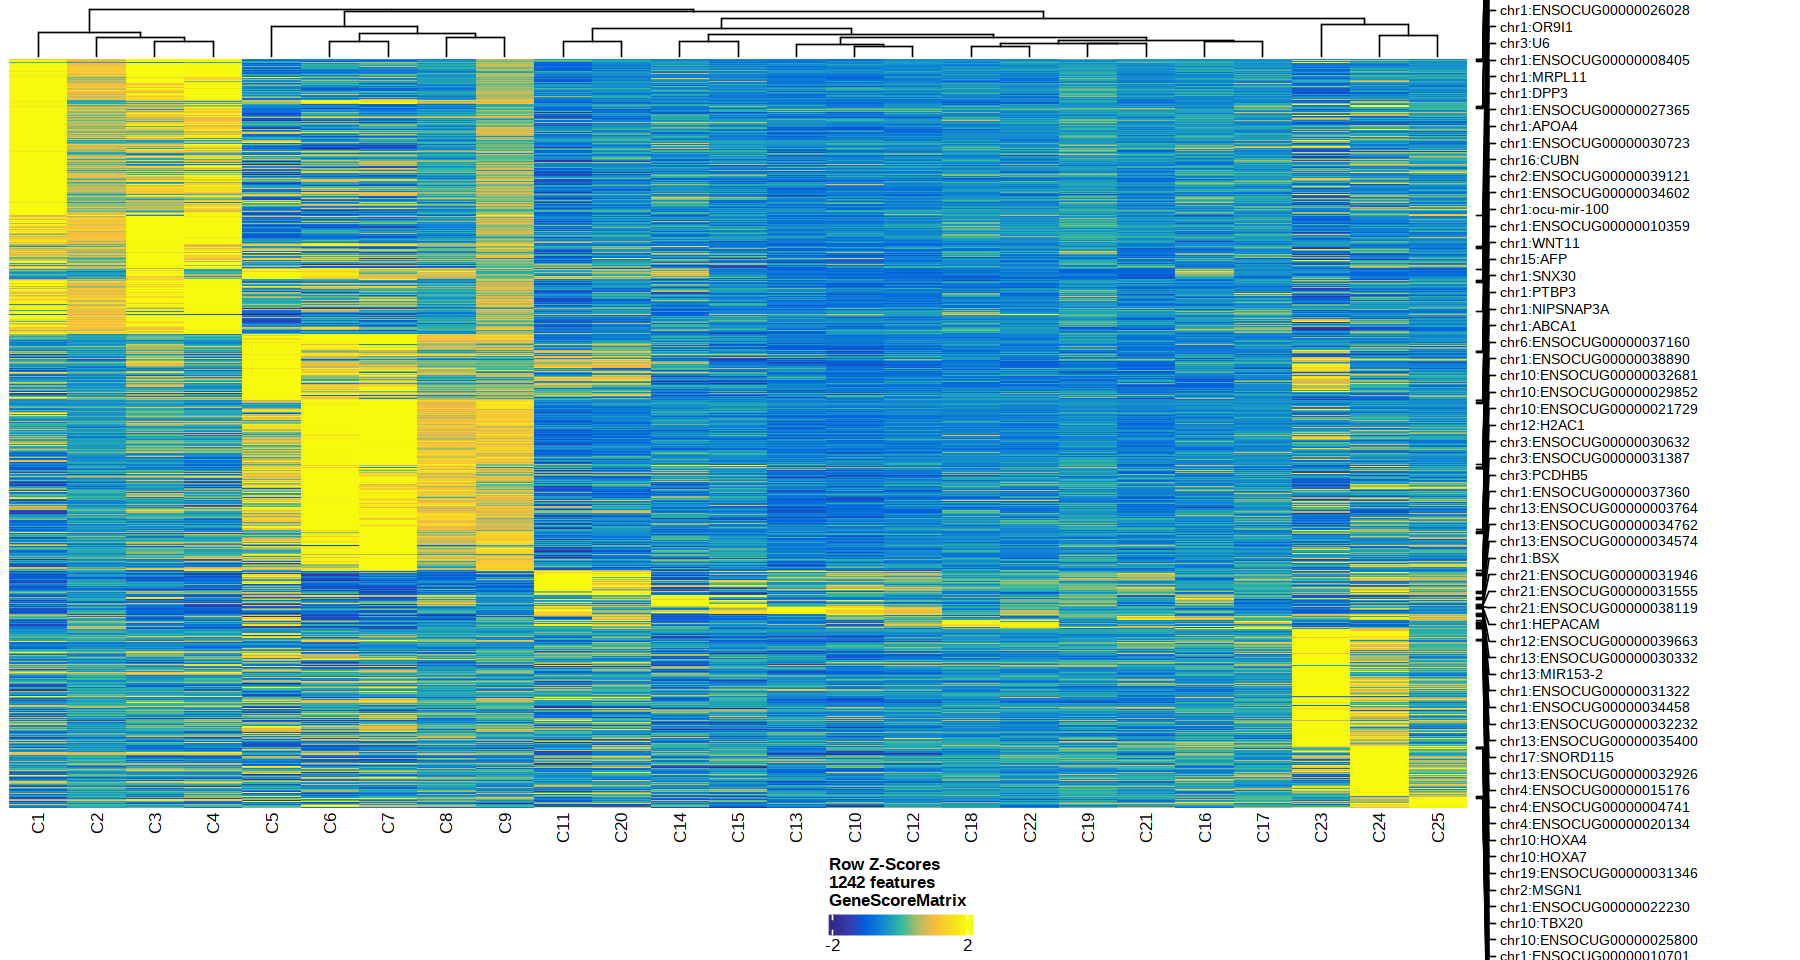

In [7]:
# Markers GeneScoreMatrix
suppressMessages(find_markers('GeneScoreMatrix', ntop=4))

  [1] "chr1:ENSOCUG00000010170"  "chr1:VCP"                
  [3] "chr1:UBE2R2"              "chr1:ENSOCUG00000026843" 
  [5] "chr1:ENSOCUG00000032761"  "chr1:ENSOCUG00000005752" 
  [7] "chr13:AGAP3"              "chr13:ENSOCUG00000036962"
  [9] "chr1:ENSOCUG00000022518"  "chr1:FBXO10"             
 [11] "chr1:PIGO"                "chr1:ENSOCUG00000031760" 
 [13] "chr1:ENSOCUG00000016631"  "chr1:ENSOCUG00000000524" 
 [15] "chr1:ARHGAP32"            "chr1:ENSOCUG00000022230" 
 [17] "chr1:NIPSNAP3A"           "chr1:ENSOCUG00000029006" 
 [19] "chr13:SNX27"              "chr13:ENSOCUG00000014622"
 [21] "chr1:PTPN3"               "chr1:ENSOCUG00000039058" 
 [23] "chr1:GBA2"                "chr1:SIGMAR1"            
 [25] "chr1:ENSOCUG00000025908"  "chr1:KANK1"              
 [27] "chr1:SPTLC1"              "chr1:ENSOCUG00000032592" 
 [29] "chr1:ENSOCUG00000030214"  "chr1:GALNT12"            
 [31] "chr1:DENND4C"             "chr1:OPCML"              
 [33] "chr1:ENSOCUG00000022894"  "chr16:

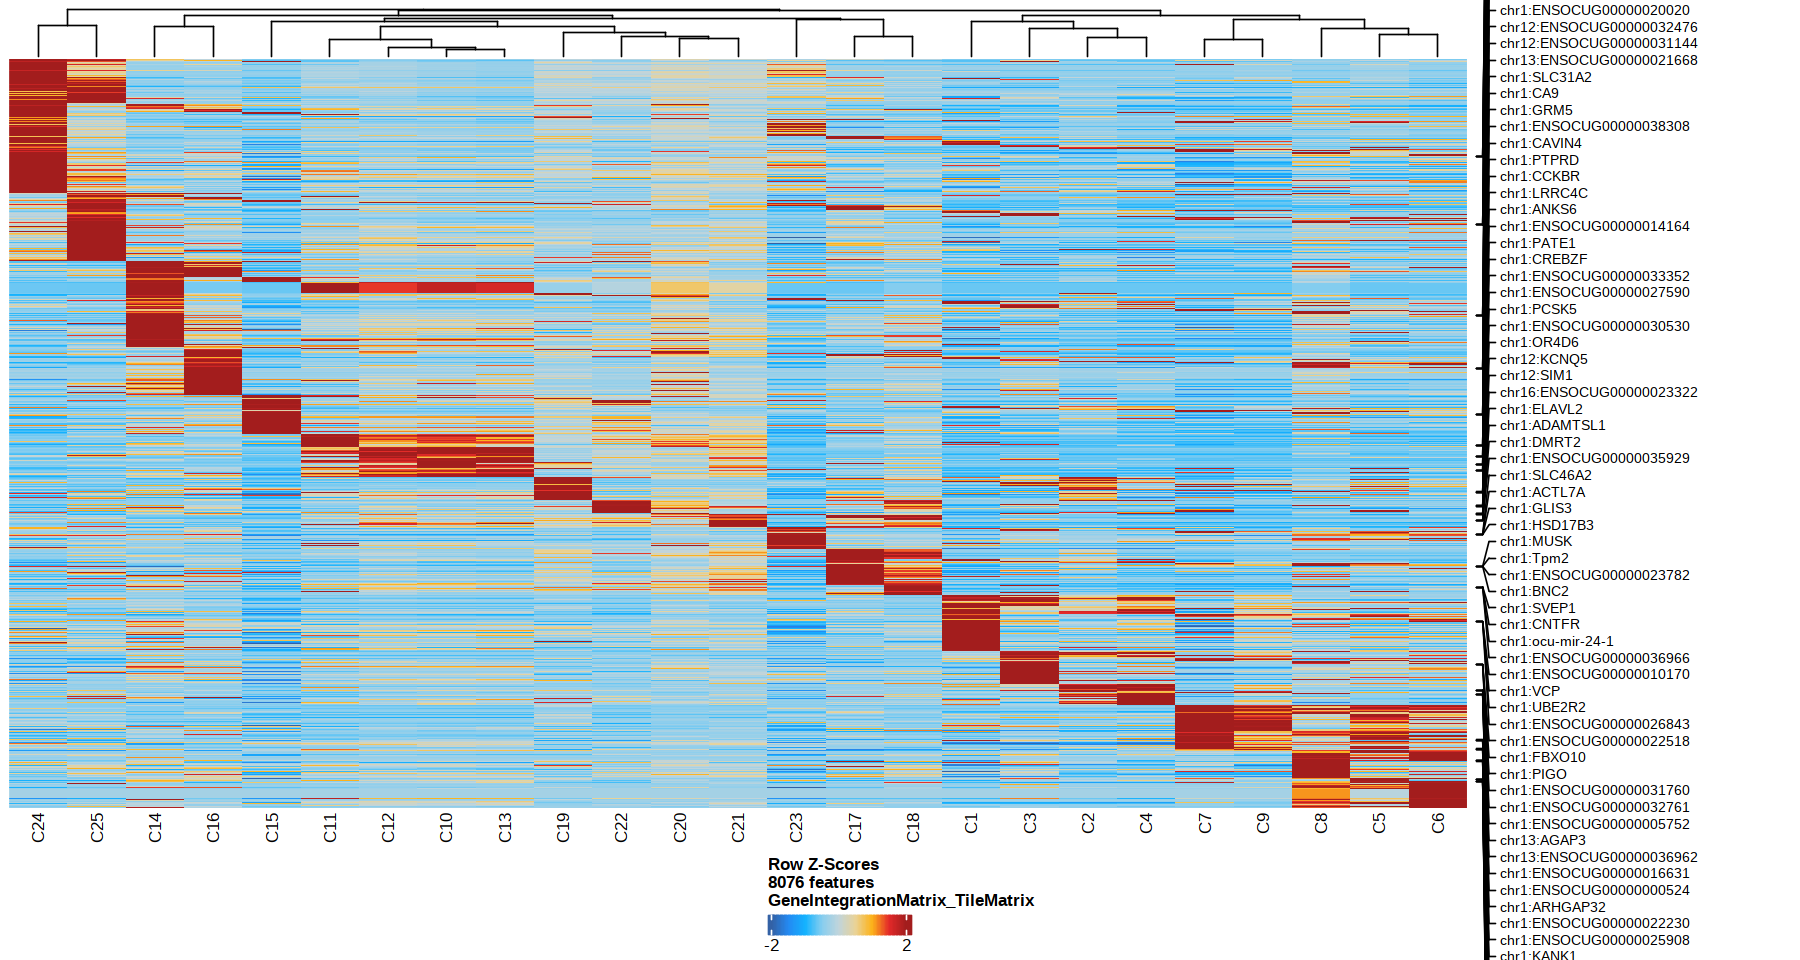

In [8]:
# Markers GeneScoreMatrix
suppressMessages(find_markers('GeneIntegrationMatrix_TileMatrix', ntop=4))

# Label Clusters

In [119]:
# Clusters too large, this is not used
reannotation = data.frame(
    Clusters_PeakMatrix = paste0('C', 1:25),
    celltype_manual = c('SCT', #1
                       'CYT',#2
                       'Trophoblast',#3
                       'CYT',#4
                       'YS_endoderm?',#5
                       'Hypoblast',#6
                       'Hypoblast',#7
                       'Anterior_Hypoblast?',#8
                       'Hypoblast',#9
                       'Embryo_proper',#10
                       'Embryo_proper',#11
                       'Embryo_proper',#12
                       'Embryo_proper',#13
                       'Epiblast',#14
                       'Early_Erythrocytes?',#15
                       'Primitive_Streak',#16
                       'Embryo_proper',#17
                       'Embryo_proper',#18
                       '??????',#19
                       'Embryo_proper',#20
                       'Embryo_proper',#21
                       'Embryo_proper',#22
                       'Late_Erythrocytes',#23
                       'Megakaryocytes',#24
                       'Endothelium'))#25 

In [120]:
# Add metadata
ArchRProject@cellColData$cell = rownames(ArchRProject@cellColData)
cells = rownames(ArchRProject@cellColData)
ArchRProject@cellColData = merge(ArchRProject@cellColData, reannotation, by='Clusters_PeakMatrix')

ArchRProject@cellColData = ArchRProject@cellColData[order(ArchRProject@cellColData$cell, cells),]
rownames(ArchRProject@cellColData) = ArchRProject@cellColData$cell

In [194]:
# Reannotate with refinded clusters
reannotation = list(
    'Anterior Hypoblast'= c('GD7_C11','GD7_C5','GD7_C12','GD7_C9'),
    'Hypoblast'= c('GD7_C10', 'GD7_C7','GD7_C6','GD7_C8'),
    'Trophoblast'= c('GD7_C4', 'GD7_C1','GD7_C2','GD7_C3', 'GD8_C4'),
    'Epiblast'= c('GD7_C19', 'GD7_C16','GD8_C11','GD7_C15', 'GD7_C17','GD7_C14'),
    'Haematoendothelial progenitors'= c('GD7_C13'),
    'Primitive Streak'= c('GD7_C18'),
    'Visceral YS Endoderm'= c('GD8_C7', 'GD9_C5', 'GD8_C8'),
    'SCT'= c('GD8_C1', 'GD8_C3'),
    'Somitic Mesoderm'= c('GD8_C9', 'GD9_C21'),
    'Anterior Mesoderm'= c('GD8_C20'),
    'Endothelium'= c('GD8_C17', 'GD9_C14'),
    'NMP'= c('GD8_C10', 'GD8_C12'),
    'Placodes'= c('GD8_C14'),
    'Late Amniotic Ectoderm'= c('GD8_C15', 'GD8_C16'),
    'CYT'= c('GD8_C5', 'GD8_C6'),
    'EXE mesoderm'= c('GD8_C19'),
    'Erythrocytes'= c('GD9_C2', 'GD9_C3', 'GD9_C4', 'GD8_C18'),
    'Megakaryocytes'= c('GD9_C13'),
    'Allantois'= c('GD9_C15'),
    'Amniotic Ectoderm' = c('GD9_C1'),
    'posterior mesoderm' = c('GD8_C21','GD9_C16'),
    'unkown' = c('GD9_C20','GD9_C6','GD8_C13','GD9_C12',
                'GD9_C8','GD9_C11','GD9_C10','GD9_C7','GD9_C9',
                'GD9_C17','GD9_C19',
                'GD9_C18','GD9_C22', 'GD8_C2')
    )



reannotation = lapply(reannotation, as.data.frame)
for(i in names(reannotation)){
reannotation[[i]]$celltype=i
}
reannotation = rbindlist(reannotation)
colnames(reannotation) = c('stage_clusters.3', 'celltype_manual_refined')

In [132]:
# Reannotate with refinded clusters
reannotation = list(
    'Anterior Hypoblast'= c('GD7_C11','GD7_C5','GD7_C12','GD7_C9'),
    'Hypoblast'= c('GD7_C10', 'GD7_C7','GD7_C6','GD7_C8'),
    'Trophoblast'= c('GD7_C4', 'GD7_C1','GD7_C2','GD7_C3', 'GD8_C4'),
    'Epiblast'= c('GD7_C19', 'GD7_C16','GD8_C11','GD7_C15', 'GD7_C17'),
    'Haematoendothelial progenitors'= c('GD7_C13'),
    'Primitive Streak'= c('GD7_C18', 'GD7_C14'),
    'Visceral YS Endoderm'= c('GD8_C7', 'GD9_C5', 'GD8_C8'),
    'SCT'= c('GD8_C1', 'GD8_C3'),
    'Somitic Mesoderm'= c('GD8_C9'),
    'Anterior Mesoderm'= c('GD8_C20'),
    'Endothelium'= c('GD8_C17', 'GD9_C14'),
    'NMP'= c('GD8_C10', 'GD8_C21'),
    'Placodes'= c('GD8_C14'),
    'Late Amniotic Ectoderm'= c('GD8_C15', 'GD8_C16'),
    'CYT'= c('GD8_C5', 'GD8_C6'),
    'Early Erythrocytes'= c('GD8_C18'),
    'EXE mesoderm'= c('GD8_C19'),
    'Late Erythrocytes'= c('GD9_C2', 'GD9_C3', 'GD9_C4'),
    'Megakaryocytes'= c('GD9_C13'),
    'Allantois'= c('GD9_C15'),
    'Amniotic Ectoderm' = c('GD9_C1'),
    'unkown' = c('GD9_C20','GD9_C6','GD8_C13','GD9_C12',
                'GD9_C8','GD9_C11','GD9_C10','GD9_C7','GD9_C9',
                'GD8_C12', 'GD9_C17','GD9_C21','GD9_C19',
                'GD9_C18','GD9_C16','GD9_C22', 'GD8_C2')
    )



reannotation = lapply(reannotation, as.data.frame)
for(i in names(reannotation)){
reannotation[[i]]$celltype=i
}
reannotation = rbindlist(reannotation)
colnames(reannotation) = c('stage_clusters.3', 'celltype_manual_refined')

In [195]:
# Add metadata
ArchRProject@cellColData$cell = rownames(ArchRProject@cellColData)
cells = rownames(ArchRProject@cellColData)
ArchRProject@cellColData = merge(ArchRProject@cellColData, reannotation, by='stage_clusters.3')

ArchRProject@cellColData = ArchRProject@cellColData[order(ArchRProject@cellColData$cell, cells),]
rownames(ArchRProject@cellColData) = ArchRProject@cellColData$cell

In [196]:
colnames((ArchRProject@cellColData))

[1] "stage_clusters.3"                    
 [2] "sample"                              
 [3] "Sample"                              
 [4] "TSSEnrichment"                       
 [5] "ReadsInTSS"                          
 [6] "ReadsInPromoter"                     
 [7] "PromoterRatio"                       
 [8] "PassQC"                              
 [9] "NucleosomeRatio"                     
[10] "nMultiFrags"                         
[11] "nMonoFrags"                          
[12] "nFrags"                              
[13] "nDiFrags"                            
[14] "DoubletScore"                        
[15] "DoubletEnrichment"                   
[16] "stage"                               
[17] "cell"                                
[18] "stage_mapping"                       
[19] "predictedCell_Un"                    
[20] "predictedGroup_celltype_TileMatrix"  
[21] "predictedScore_celltype"             
[22] "stage_clusters"                      
[23] "cell.1"                              
[24] "Clusters_TileMatrix"                 
[25] "ReadsInPeaks"                        
[26] "FRIP"                                
[27] "predictedCell_Un.1"                  
[28] "predictedGroup_celltype_PeakMatrix"  
[29] "predictedScore_celltype.1"           
[30] "stage_clusters.1"                    
[31] "cell.2"                              
[32] "Clusters_PeakMatrix"                 
[33] "predictedCell_Un.2"                  
[34] "predictedGroup_celltype_TileMatrix.1"
[35] "predictedScore_celltype.2"           
[36] "stage_clusters.2"                    
[37] "cell.3"                              
[38] "predictedCell_Un.3"                  
[39] "predictedGroup_celltype_PeakMatrix.1"
[40] "predictedScore_celltype.3"           
[41] "cell.4"                              
[42] "celltype_manual_refined"

In [197]:
archr_meta = as.data.frame(getCellColData(ArchRProject))

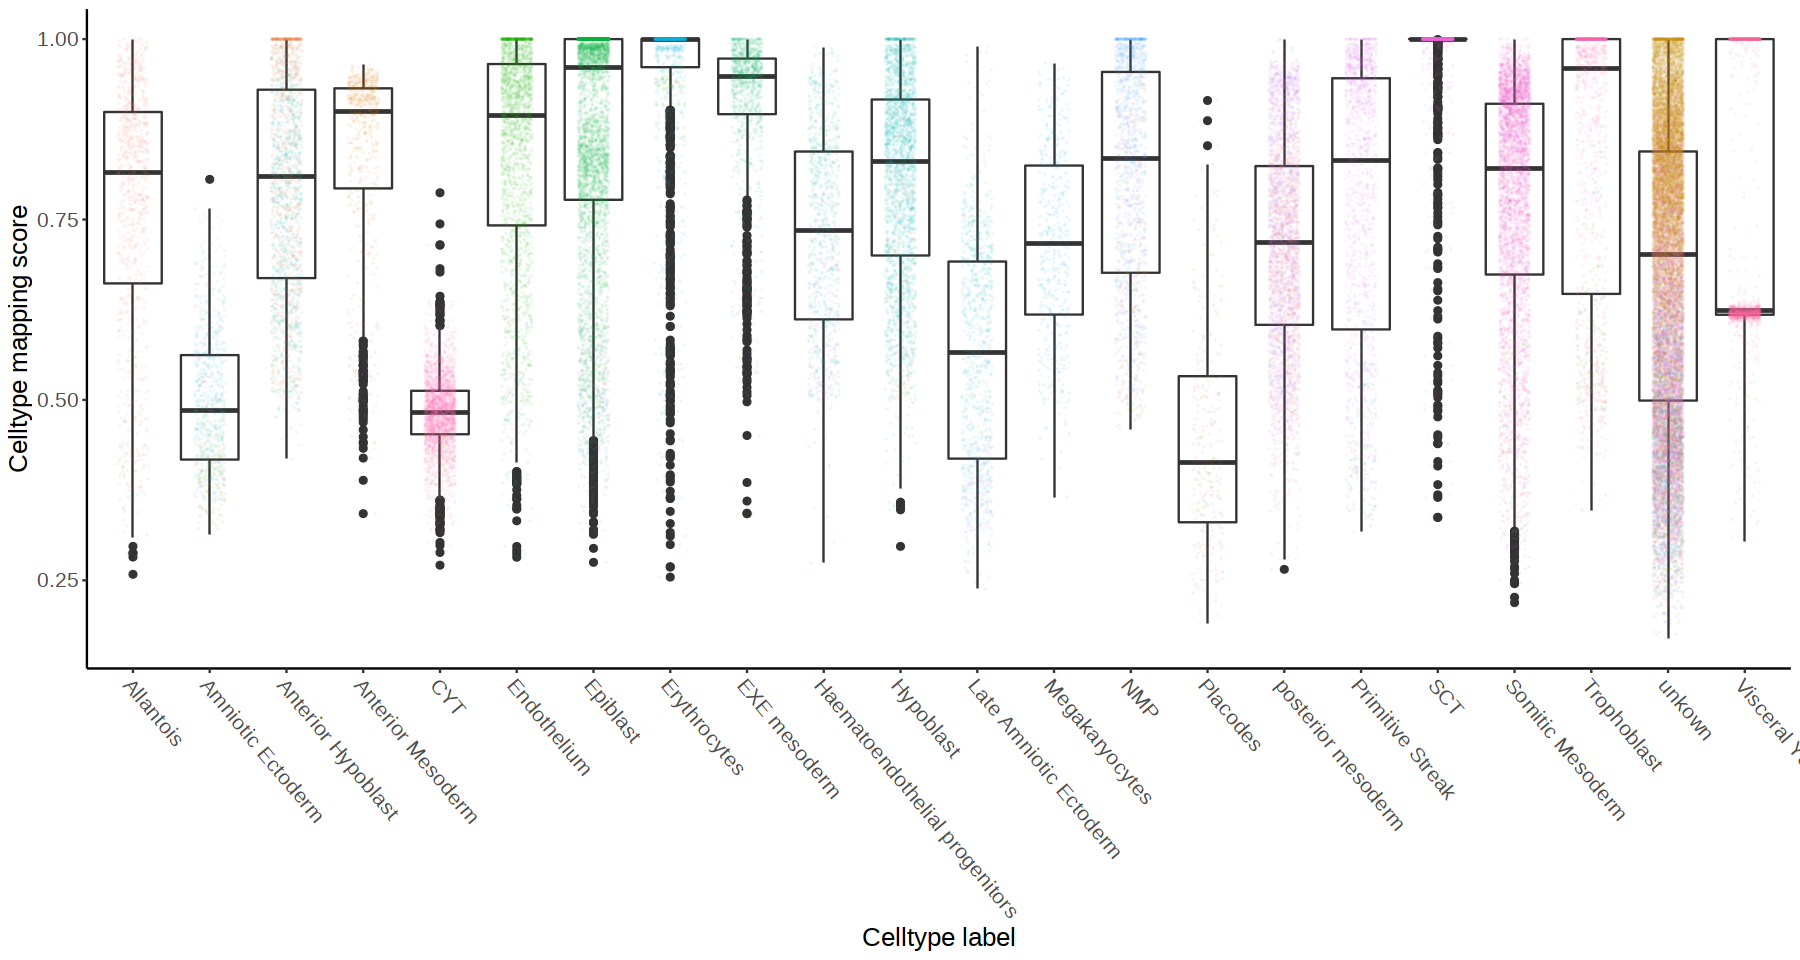

In [207]:
options(repr.plot.width=15, repr.plot.height=8)

ggplot(archr_meta, aes(celltype_manual_refined, predictedScore_celltype.3)) + 
        geom_boxplot() + 
        geom_jitter(position=position_jitter(0.2), size = 0.001, alpha = 0.05, aes(col=predictedGroup_celltype_PeakMatrix.1)) + 
        xlab('Celltype label') + ylab('Celltype mapping score') + 
        theme_classic() + theme(text = element_text(size=15, color='black'),
                                axis.text.x=element_text(angle=-50, hjust=0),
                               legend.position='none')

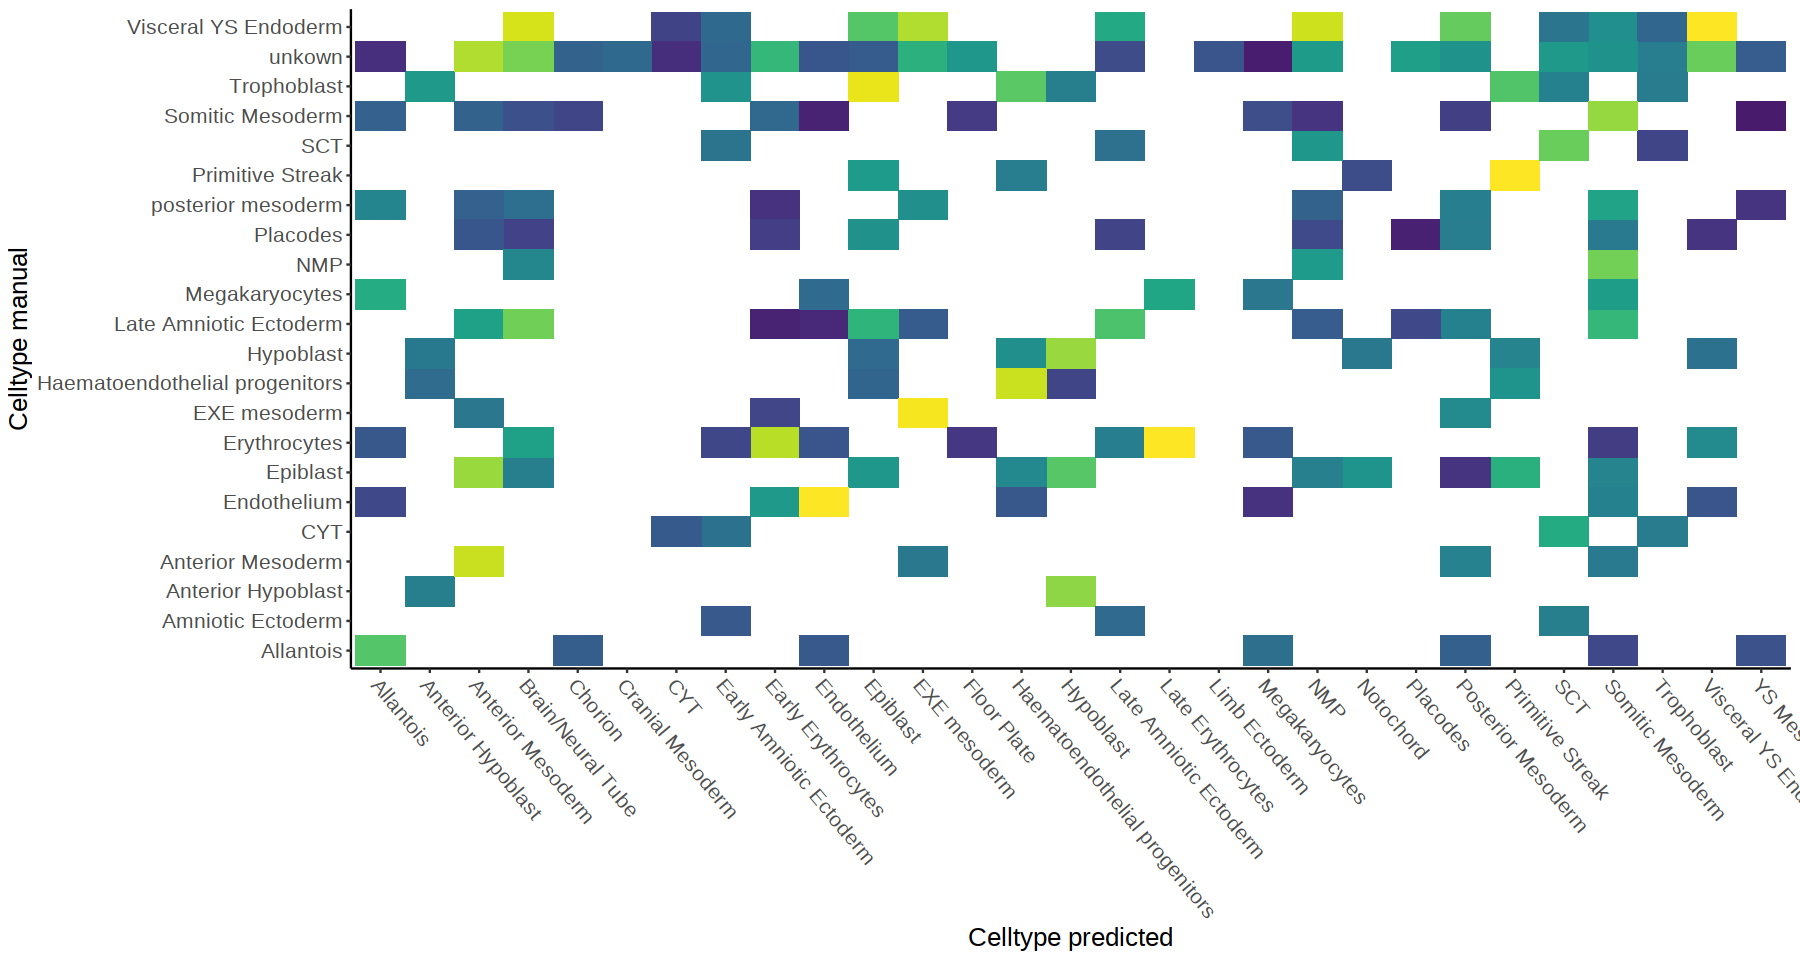

In [203]:
options(repr.plot.width=15, repr.plot.height=8)

ggplot(archr_meta, aes(predictedGroup_celltype_PeakMatrix.1, celltype_manual_refined,  fill=predictedScore_celltype.3)) + 
        geom_tile() +
        scale_fill_viridis() +
        xlab('Celltype predicted') + ylab('Celltype manual') + 
        theme_classic() + theme(text = element_text(size=15, color='black'),
                                axis.text.x=element_text(angle=-50, hjust=0),
                               legend.position='none')

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-1c0eb66b1f34d-Date-2022-01-12_Time-19-04-21.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 
Length of unique values greater than palette, interpolating..



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-1c0eb66b1f34d-Date-2022-01-12_Time-19-04-21.log



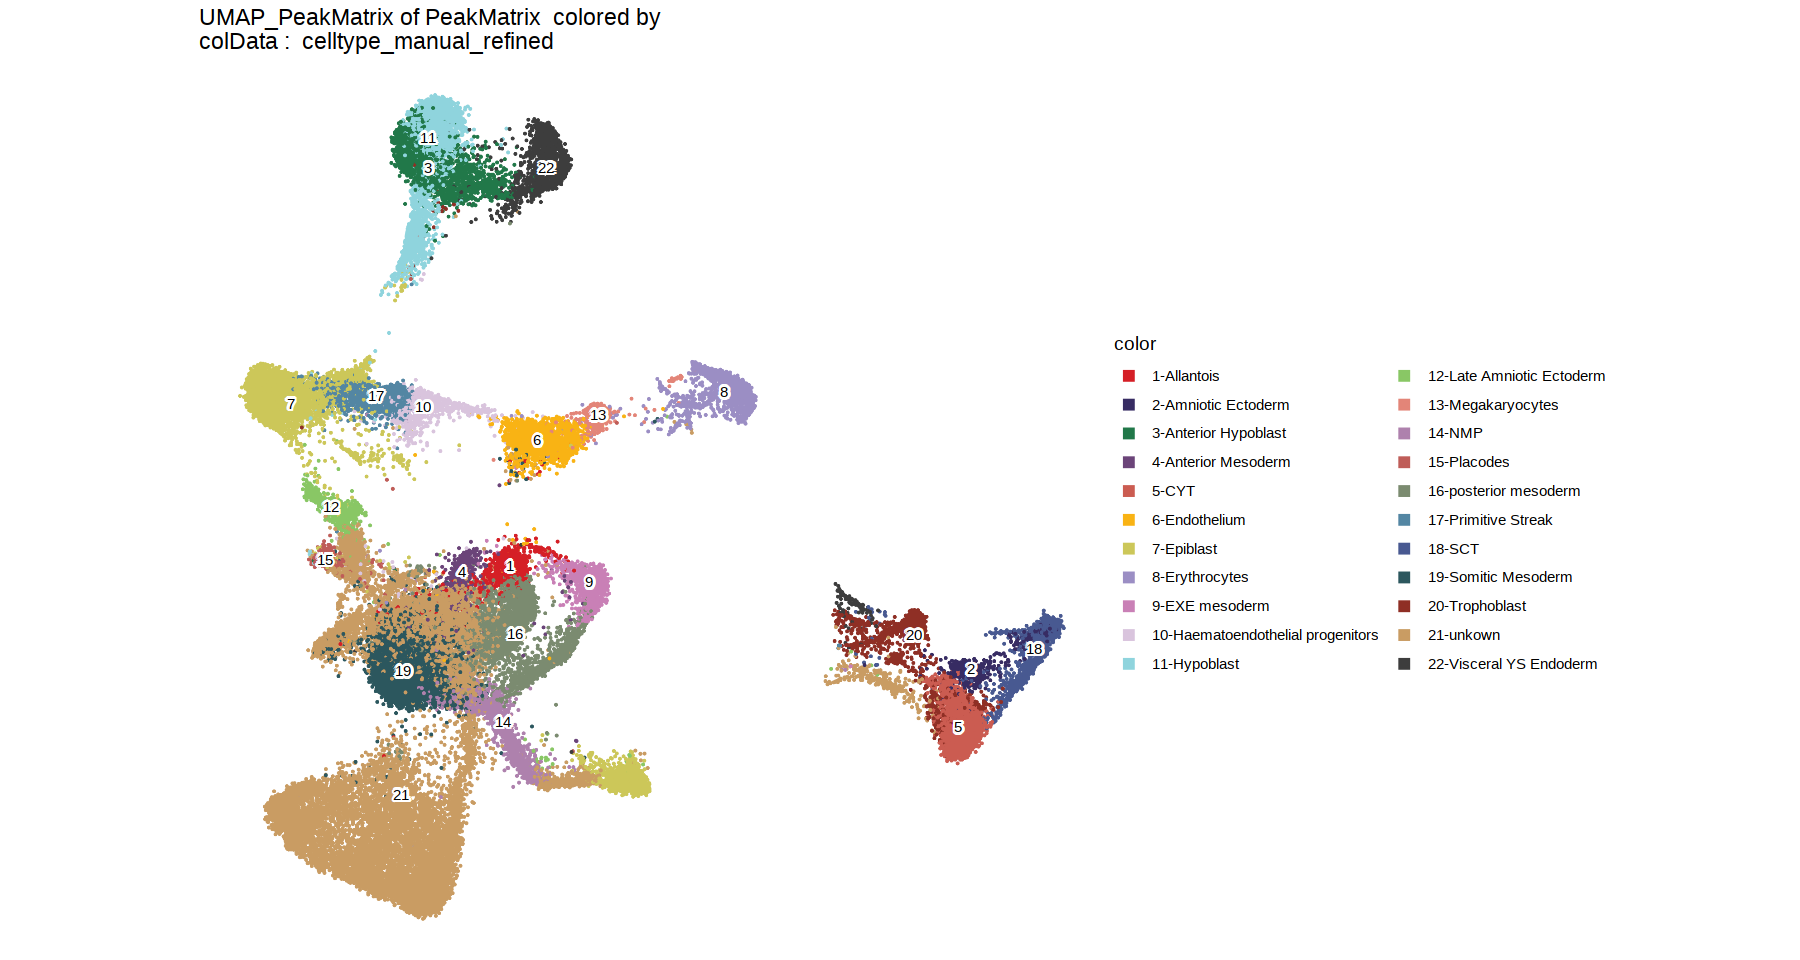

In [204]:
plotEmbedding(
    ArchRProj = ArchRProject, 
    colorBy = "cellColData", 
    name = 'celltype_manual_refined', 
    embedding = "UMAP_PeakMatrix"
) + theme_void()

In [208]:
saveArchRProject(ArchRProj = ArchRProject)

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(42): stage_clusters.3 sample ... cell.4
  celltype_manual_refined
numberOfCells(1): 50525
medianTSS(1): 3.353
medianFrags(1): 34982